In [ ]:
"""Acceptance tests on the modules of lib"""

'Acceptance tests on the modules of lib'

In [1]:
#basic imports
import numpy as np
import pytest
import matplotlib.pyplot as plt

### Cosmology core

In [2]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
from lib.cosmology import FLRW

#fiducial cosmology parameters
cosmo = FLRW(H0=70.0, omega_m=0.3, omega_lambda=0.7)

#### $E(z)^2 = \Omega_m (1+z)^3 + \Omega_k (1+z)^2 + \Omega_{\lambda}$

In [3]:
# Test if E(0) = 1
#E is inside class FLRW
E_0 = cosmo.E(0)
print(E_0)

1.0


#### Low z Hubble law: $\mu(z) \approx 5 log_{10}(\frac{cz}{H0}) + 25$

In [4]:
z = 1e-4
C_KM_S = 299792.458
mu = float(np.squeeze(cosmo.mu(z)))
mu_hubble = 5*np.log10(C_KM_S*z/cosmo.H0) + 25
if mu == pytest.approx(mu_hubble, abs=1e-3):
    print("Low-z Hubble law test passed")
else:
    print("Low-z Hubble law test failed")

Low-z Hubble law test passed


#### $D_M = \chi$, $\Omega_k = 0$

In [5]:
z = np.linspace(0.01, 2.0, 20)
chi = cosmo.chi(z)
d_m = cosmo.D_M(z)
if np.allclose(d_m, chi, rtol=1e-10):
    print("Transverse distance equals comoving distance test passed")
else:
    print("Transverse distance equals comoving distance test failed")

Transverse distance equals comoving distance test passed


#### $D_L = (1+z)^2D_A$

In [6]:
dl = cosmo.D_L(z)
da = cosmo.D_A(z)
dl_th = ((1+z)**2)*da

if dl == pytest.approx(dl_th, abs=1e-3):
    print("Luminosity distance and angular diameter distance relation test passed")
else:
    print("Luminosity distance and angular diameter distance relation test failed")

Luminosity distance and angular diameter distance relation test passed


## Baysean core

In [7]:
from lib.bayes import GaussianRandomWalk, MetropolisHastings, Posterior, Likelihood, flat_log_prior, TuneProp

#### Recovery of gaussian target

In [8]:
#gaussian posterior with flat prior to be recovered
def gaussian_posterior(mean, cov):
    inv_cov = np.linalg.inv(cov)

    def log_likelihood(theta):
        diff = theta - mean
        return -0.5 * diff @ inv_cov @ diff

    def log_prior(theta):
        return 0.0
    return Posterior(log_likelihood, log_prior)

In [9]:
def recover_gaussian_target(mean, cov):
    posterior = gaussian_posterior(mean, cov)
    proposal = GaussianRandomWalk(cov, dt=1.5)
    sampler = MetropolisHastings(posterior, proposal)

    result = sampler.sample(theta0=mean, n_steps=20000, rng=0)
    samples = result.samples[2000:] # burn-in
    return result, samples


In [10]:
mean = np.array([1.0, -2.0])
cov = np.array([[1.0, 0.3], [0.3, 0.5]])

result, samples = recover_gaussian_target(mean, cov)

print("Sample mean:", samples.mean(axis=0))
print("Sample covariance:\n", np.cov(samples.T))

if np.allclose(samples.mean(axis=0), mean, atol=0.1):
    print("Sample mean is close to the true mean.")
else:
    print("Sample mean is not close to the true mean.")

if np.allclose(np.cov(samples.T), cov, atol=0.15):
    print("Sample covariance is close to the true covariance.")
else:
    print("Sample covariance is not close to the true covariance.")
if 0.1 < result.acceptance_rate < 0.9:
    print("Acceptance rate is within the expected range.")
else:
    print("Acceptance rate is outside the expected range.")

Sample mean: [ 1.03665512 -1.98919416]
Sample covariance:
 [[1.03359774 0.31463619]
 [0.31463619 0.50501073]]
Sample mean is close to the true mean.
Sample covariance is close to the true covariance.
Acceptance rate is within the expected range.


#### Reproduce runs from seed

In [11]:
def sampler_from_seed(seed):
    mean = np.zeros(2)
    cov = np.eye(2)
    posterior = gaussian_posterior(mean, cov)
    proposal = GaussianRandomWalk(cov, dt=1.0)

    result = MetropolisHastings(posterior, proposal).sample(mean, n_steps=500, rng=seed)
    return result


In [12]:
result_a = sampler_from_seed(25)
result_b = sampler_from_seed(25)

rejected_a = ~result_a.accepted
rejected_b = ~result_b.accepted

if np.array_equal(result_a.samples, result_b.samples):
    print("Samples are equal.")
else:
    print("Samples are not equal.")

if np.array_equal(rejected_a, rejected_b):
    print("Rejected arrays are equal.")
else:
    print("Rejected arrays are not equal.")

Samples are equal.
Rejected arrays are equal.


## Union2.1 analysis

In [38]:
from scripts.dataset import load_union21
from lib.diagnostics import split_rhat

DATA_DIR = Path.cwd().parent / "data"
data = load_union21(DATA_DIR, include_systematics=True)
print(f"Loaded {len(data)} supernovae from Union2.1")

Loaded 580 supernovae from Union2.1


#### Data and covariance dimensions

In [15]:
n = len(data.z)
is_square = data.cov.shape == (n, n)
is_symmetric = np.allclose(data.cov, data.cov.T)
eigvals = np.linalg.eigvalsh(data.cov)

if is_square and is_symmetric:
    print(f"Covariance dimension is nxn: {n}x{n}, symmetric, with min eigval={eigvals.min():.2e}")
else:
    print("Covariance dimension check failed")

Covariance dimension is nxn: 580x580, symmetric, with min eigval=7.47e-03


#### Likelihood with Cholesky solves

In [16]:
likelihood = Likelihood(data, H0=70.0)
chi2_fid = likelihood.chi2(omega_m=0.3, omega_lambda=0.7)
print(f"chi2/N for (Om=0.3, OL=0.7) = {chi2_fid/n:.3f}")

chi2/N for (Om=0.3, OL=0.7) = 0.940


#### Dispersed chains

In [ ]:
#pilot-tune of proposal: approximate the posterior's covariance 
#regularize and freeze result
log_prior = flat_log_prior([(0.0, 2.0), (-1.0, 3.0)])
posterior = Posterior(likelihood, log_prior)

n_rounds = 5
n_steps_round = 2000
target_acceptance = (0.2, 0.4)
jitter = 1e-6 #regularizes the covariance estimate

theta0 = np.array([0.3, 0.7]) #fiducial cosmology
cov = np.eye(2) #initial guess for proposal covariance

tuned_result = TuneProp.tune_proposal(posterior, theta0, cov, n_rounds, n_steps_round, target_acceptance, jitter)
tuned_proposal = tuned_result.proposal
print("\nfrozen proposal covariance:\n", tuned_proposal.cov)

/home/robertavassallo/Projects/COSMO_NUM/repo_mcmc_supernovae/lib/cosmology.py:35: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(self.omega_m*(1 + z)**3 + self.omega_k*(1 + z)**2 + self.omega_lambda)
/home/robertavassallo/Projects/COSMO_NUM/repo_mcmc_supernovae/lib/cosmology.py:73: RuntimeWarning: invalid value encountered in log10
  return 5*np.log10(self.D_L(z)) + 25



frozen proposal covariance:
 [[0.03573543 0.05385338]
 [0.05385338 0.11521022]]


In [29]:
sampler = MetropolisHastings(posterior, tuned_proposal)

#dispersed starting points across the prior
starts = [np.array([0.1, 0.2]), np.array([0.5, -0.9]), np.array([1.8, 0.7]), np.array([1.0, 2.0])]
n_steps = 25000
results = [sampler.sample(theta0=s0, n_steps=n_steps, rng=seed) for seed, s0 in enumerate(starts)]

for i, r in enumerate(results):
    print(f"chain {i}: start={starts[i]}, acceptance={r.acceptance_rate:.2f}")

chain 0: start=[0.1 0.2], acceptance=0.36
chain 1: start=[ 0.5 -0.9], acceptance=0.36
chain 2: start=[1.8 0.7], acceptance=0.37
chain 3: start=[1. 2.], acceptance=0.36


## Convergence report

In [20]:
from lib.diagnostics import trace_plot, acceptance_plot, convergence_report, power_spectrum, fit_power_spectrum, log_binned_trend

#### Trace and acceptance plots

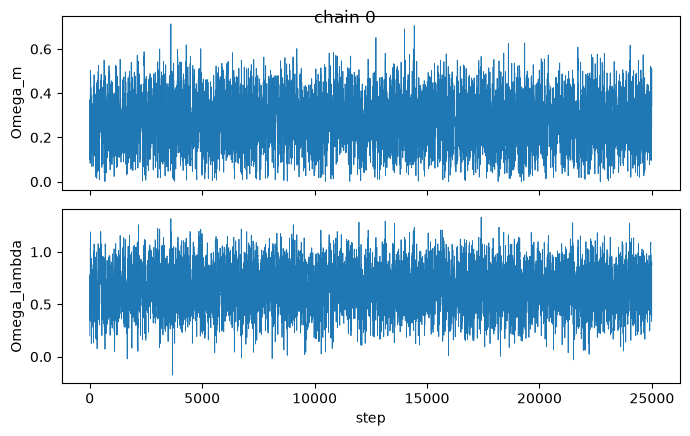

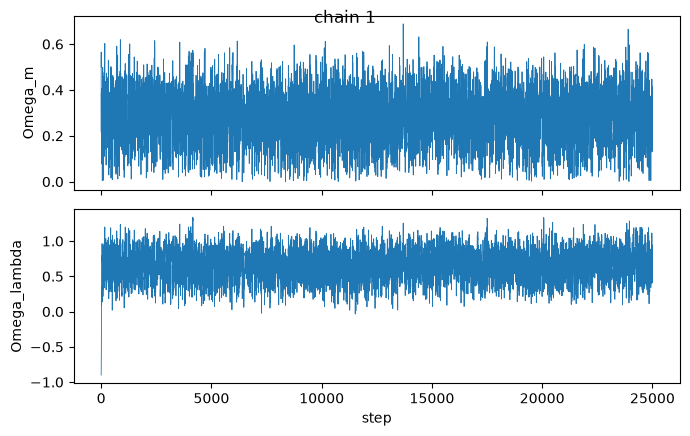

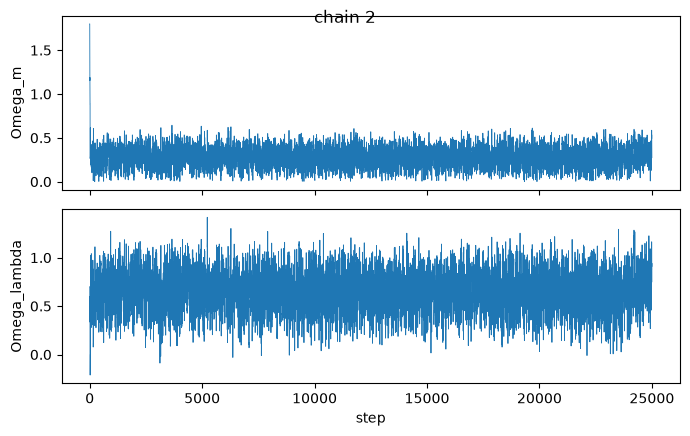

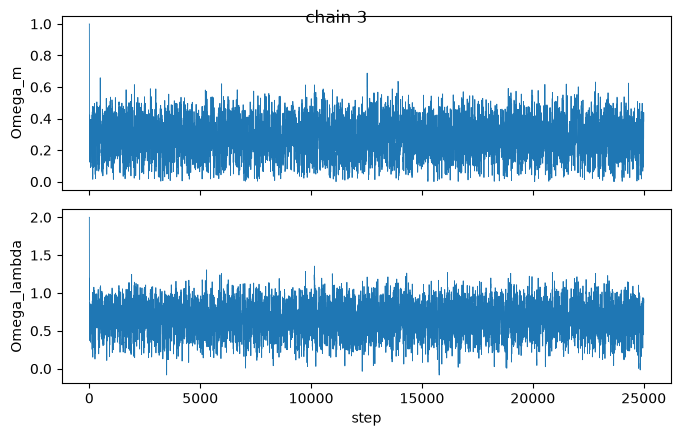

In [30]:
for i, r in enumerate(results):
    fig = trace_plot(r.samples, param_names=["Omega_m", "Omega_lambda"])
    fig.suptitle(f"chain {i}")

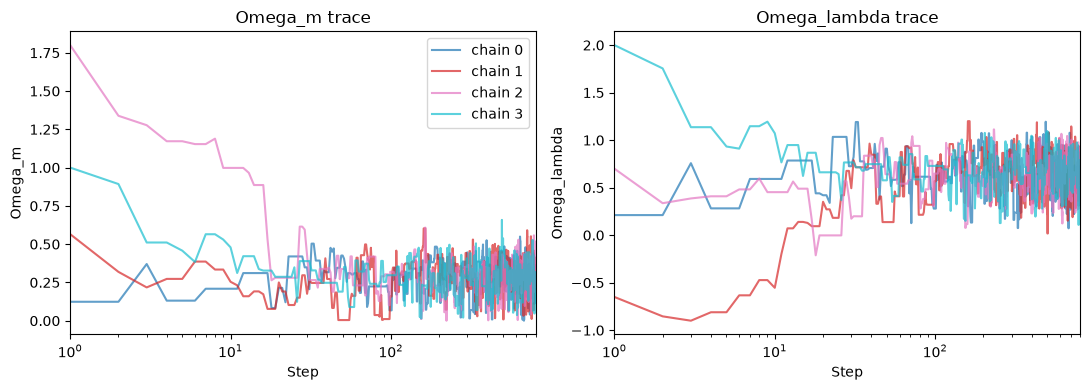

In [31]:
#zoom in on steps
colors = plt.cm.tab10(np.linspace(0, 1, len(results)))
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, name, param_idx in zip(axes, ["Omega_m", "Omega_lambda"], range(2)):
    for i, r in enumerate(results):
        ax.plot(r.samples[:, param_idx], color=colors[i], alpha=0.7, label=f"chain {i}")
    ax.set_xlim(1, 800)
    ax.set_xscale("log")
    ax.set_xlabel("Step")
    ax.set_ylabel(name)
    ax.set_title(f"{name} trace")
axes[0].legend()
fig.tight_layout()

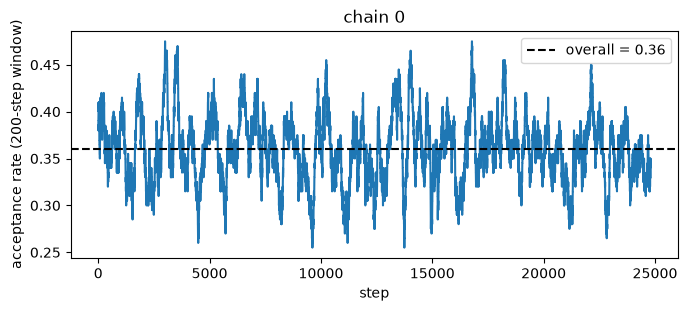

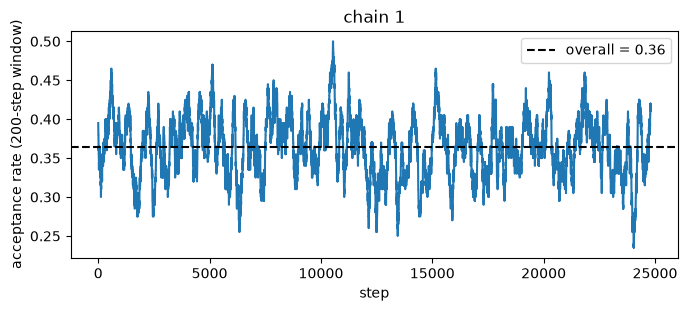

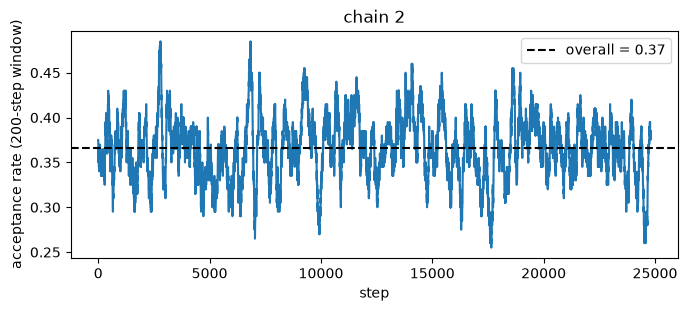

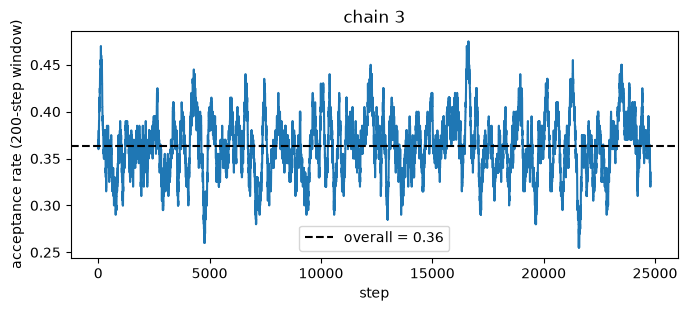

In [32]:
for i, r in enumerate(results):
    fig = acceptance_plot(r.accepted, window=200)
    fig.axes[0].set_title(f"chain {i}")

window = 8 steps (~chains' autocorrelation time)


/tmp/ipykernel_359404/2521762660.py:14: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(0, 2000)


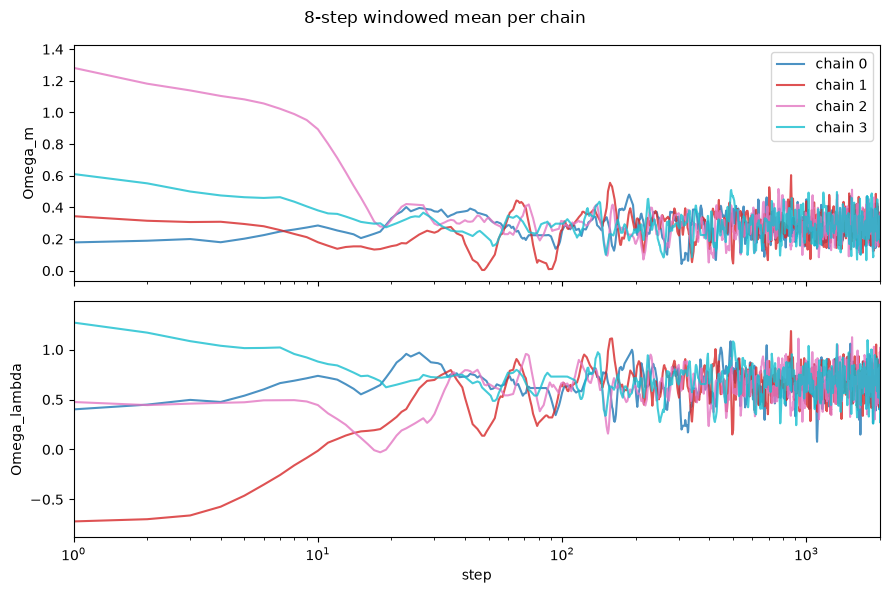

In [33]:
#means per chain within window to tune burn-in
from lib.diagnostics import integrated_autocorr_time

tau = np.mean([integrated_autocorr_time(r.samples[:, j]) for r in results for j in range(2)])
window = max(1, int(round(tau))) #window is defined by chains autocorrelation time
print(f"window = {window} steps (~chains' autocorrelation time)")

colors = plt.cm.tab10(np.linspace(0, 1, len(results)))
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
for ax, name, param_idx in zip(axes, ["Omega_m", "Omega_lambda"], range(2)):
    for i, r in enumerate(results):
        running_mean = np.convolve(r.samples[:, param_idx], np.ones(window) / window, mode="valid")
        ax.plot(running_mean, color=colors[i], alpha=0.8, label=f"chain {i}")
    ax.set_xlim(0, 2000) 
    ax.set_xscale("log")
    ax.set_ylabel(name)
axes[0].legend()
axes[-1].set_xlabel("step")
fig.suptitle(f"{window}-step windowed mean per chain")
fig.tight_layout()

In [34]:
#tunning burn-in based on visual check of above plots. since convergence happens fast, we use a burn-in of 300 steps
burn_in = 300
om_chains = np.array([r.samples[burn_in:, 0] for r in results])
ol_chains = np.array([r.samples[burn_in:, 1] for r in results])
accepted = np.array([r.accepted[burn_in:] for r in results])

#### Convergence check: $\hat{R}$, ESS and MCSE

In [35]:
report = convergence_report(
    chains={"omega_m": om_chains, "omega_lambda": ol_chains},
    accepted=accepted,
)
print('Rhat:', {k: f"{v:.3f}" for k, v in report.rhat.items()})
print('ESS:', {k: f"{v:.1f}" for k, v in report.ess.items()})
print('Tau_int:', {k: f"{v:.1f}" for k, v in report.tau_int.items()})
print('Acceptance rate:', f"{report.acceptance_rate:.3f}")
print('Passed checks:', report.passed)
if report.ok:
    print("Convergence check passed")
else:
    print("Convergence check failed")

Rhat: {'omega_m': '1.000', 'omega_lambda': '1.001'}
ESS: {'omega_m': '13458.3', 'omega_lambda': '12900.8'}
Tau_int: {'omega_m': '7.4', 'omega_lambda': '7.7'}
Acceptance rate: 0.363
Passed checks: {'omega_m': True, 'omega_lambda': True}
Convergence check passed


#### Unthinned Dunkley P(k)

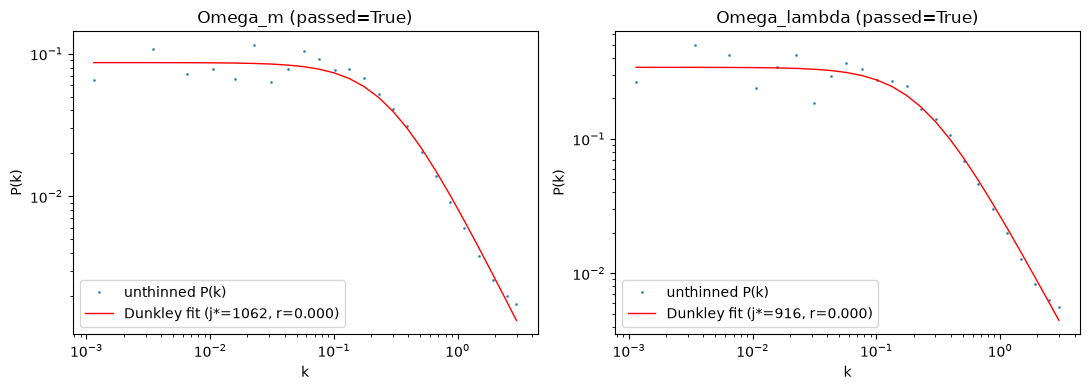

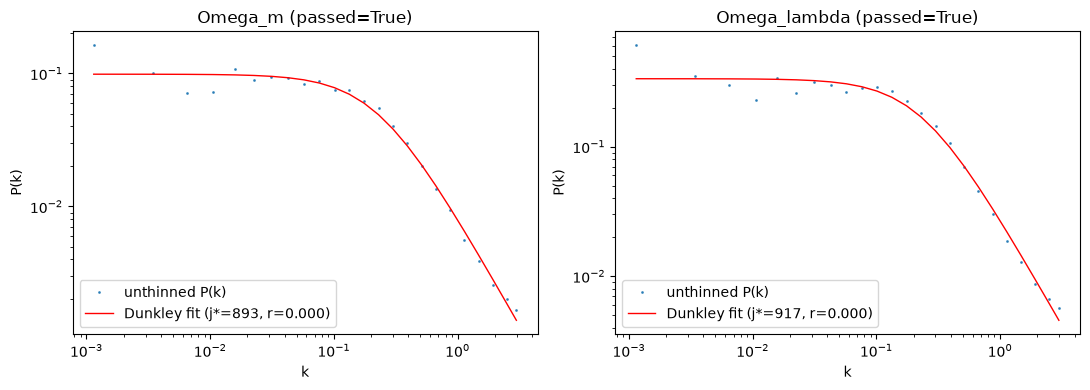

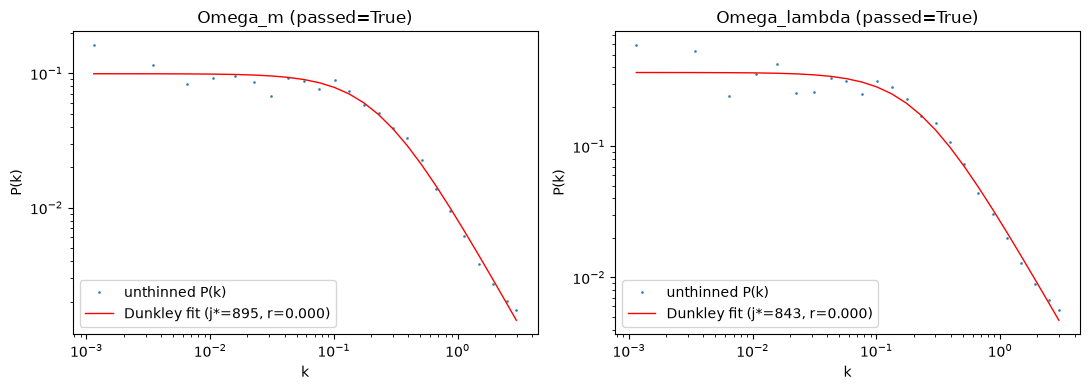

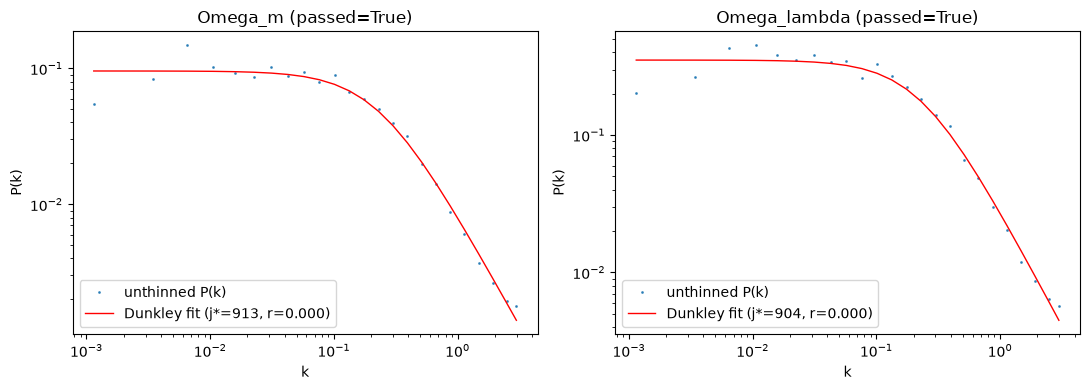

In [36]:
for m, l in zip(om_chains, ol_chains):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for ax, name, chain in zip(axes, ["Omega_m", "Omega_lambda"], [m, l]):
        k, P = power_spectrum(chain)
        k_binned, P_binned = log_binned_trend(k, P)          # unthinned: raw P(k) over every k-mode
        diag = fit_power_spectrum(chain)       # fits P0/(1+(k/k*)^alpha) to the log-binned trend

        ax.loglog(k_binned, P_binned, ".", ms=2, alpha=0.8, label="unthinned P(k)")
        ax.loglog(k_binned, diag.P0 / (1 + (k_binned / diag.k_star) ** diag.alpha), "r-", lw=1.0,
                label=f"Dunkley fit (j*={diag.j_star:.0f}, r={diag.r:.3f})")
        ax.set_xlabel("k")
        ax.set_ylabel("P(k)")
        ax.set_title(f"{name} (passed={diag.passed})")
        ax.legend()
    fig.tight_layout()


#### Contours in $(\Omega_m, \Omega_\Lambda)$

Omega_m      = 0.284 +0.110 -0.118
Omega_lambda = 0.669 +0.202 -0.219


Text(0.5, 0.98, '$\\Omega_m=0.284^{+0.110}_{-0.118}$, $\\Omega_\\Lambda=0.669^{+0.202}_{-0.219}$')

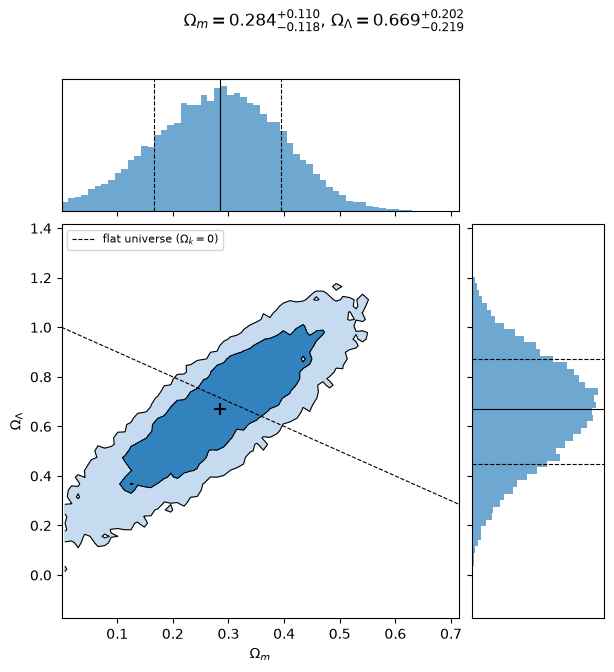

In [37]:
#posterior estimates: median with asymmetric 68% (16th/84th percentile) errors
om_samples = om_chains.ravel()
ol_samples = ol_chains.ravel()

om_lo, om_med, om_hi = np.percentile(om_samples, [16, 50, 84])
ol_lo, ol_med, ol_hi = np.percentile(ol_samples, [16, 50, 84])
print(f"Omega_m      = {om_med:.3f} +{om_hi - om_med:.3f} -{om_med - om_lo:.3f}")
print(f"Omega_lambda = {ol_med:.3f} +{ol_hi - ol_med:.3f} -{ol_med - ol_lo:.3f}")

#joint histogram + HPD levels enclosing 68%/95% of the posterior mass
H, om_edges, ol_edges = np.histogram2d(om_samples, ol_samples, bins=60)
H = H.T  #(X=Om, Y=OL)
om_centers = 0.5*(om_edges[:-1] + om_edges[1:])
ol_centers = 0.5*(ol_edges[:-1] + ol_edges[1:])

h_sorted = np.sort(H.ravel())[::-1]
cum = np.cumsum(h_sorted) / h_sorted.sum()
level_68 = h_sorted[np.searchsorted(cum, 0.68)]
level_95 = h_sorted[np.searchsorted(cum, 0.95)]

#corner plot: Om/OL marginals (with median + 68% band) around the 2D joint contour
fig, axes = plt.subplots(
    2, 2, figsize=(7, 7),
    gridspec_kw={"width_ratios": [3, 1], "height_ratios": [1, 3], "hspace": 0.05, "wspace": 0.05},
)
ax_om, ax_blank, ax_joint, ax_ol = axes[0, 0], axes[0, 1], axes[1, 0], axes[1, 1]
ax_blank.axis("off")

#Om marginal (top-left)
ax_om.hist(om_samples, bins=60, color="#3182bd", alpha=0.7)
for v, ls in [(om_med, "-"), (om_lo, "--"), (om_hi, "--")]:
    ax_om.axvline(v, color="k", lw=0.8, ls=ls)
ax_om.set_xlim(om_edges[0], om_edges[-1])
ax_om.set_yticks([])
ax_om.tick_params(labelbottom=False)

#joint 2D panel (bottom-left)
ax_joint.contourf(om_centers, ol_centers, H, levels=[level_95, level_68, H.max()],
                   colors=["#c6dbef", "#3182bd"])
ax_joint.contour(om_centers, ol_centers, H, levels=[level_95, level_68], colors="k", linewidths=0.8)
ax_joint.scatter(om_med, ol_med, marker="+", color="k", s=80)
om_line = np.linspace(0, 1.0, 100)
ax_joint.plot(om_line, 1 - om_line, "k--", lw=0.8, label=r"flat universe ($\Omega_k=0$)")
ax_joint.set_xlim(om_edges[0], om_edges[-1])
ax_joint.set_ylim(ol_edges[0], ol_edges[-1])
ax_joint.set_xlabel(r"$\Omega_m$")
ax_joint.set_ylabel(r"$\Omega_\Lambda$")
ax_joint.legend(loc="upper left", fontsize=8)

#OL marginal (bottom-right, rotated to share the joint panel's y-axis)
ax_ol.hist(ol_samples, bins=60, orientation="horizontal", color="#3182bd", alpha=0.7)
for v, ls in [(ol_med, "-"), (ol_lo, "--"), (ol_hi, "--")]:
    ax_ol.axhline(v, color="k", lw=0.8, ls=ls)
ax_ol.set_ylim(ol_edges[0], ol_edges[-1])
ax_ol.set_xticks([])
ax_ol.tick_params(labelleft=False)

fig.suptitle(
    rf"$\Omega_m={om_med:.3f}^{{+{om_hi - om_med:.3f}}}_{{-{om_med - om_lo:.3f}}}$, "
    rf"$\Omega_\Lambda={ol_med:.3f}^{{+{ol_hi - ol_med:.3f}}}_{{-{ol_med - ol_lo:.3f}}}$"
)
